Should make sure that everything(kernel entries) are real

c:\Users\rjuya\anaconda3\envs\qml_env\lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Running seeds (parallel):   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Running seeds (parallel):   0%|          | 0/10 [42:57<?, ?it/s]


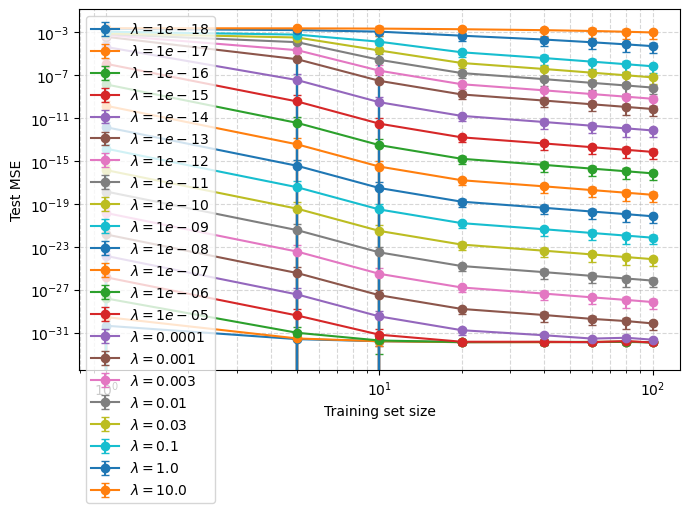

In [1]:
import pennylane as qml
import numpy as np
import cvxpy as cp

from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score
import pickle
from pathlib import Path

SEED = 42
np.random.seed(SEED)
trotter_steps = 3



# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=2
observable_terms=['X0 Y1']

# build_P function
def build_P(observable_terms):
    P=None
    for term in observable_terms:
        pieces=term.replace('+',' ').split()
        local=None
        for p in pieces:
            op=p[0].upper()
            idx=int(p[1:])
            t=getattr(qml,f'Pauli{op}')(idx)
            local=t if local is None else local@t
        P=local if P is None else P+local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
    shifted_terms = []
    for term in observable_terms:
        parts = term.replace('+', ' ').split()
        new_parts = []
        for p in parts:
            op = p[0].upper()
            idx = int(p[1:])
            new_parts.append(f"{op}{idx + circ_offset}")
        shifted_terms.append(" ".join(new_parts))
    return build_P(shifted_terms)

n_kernel=1; freq_register_sizes={0: 5, 1: 5}; n_freq=10
n_anc=1; n_circ=2; n_total=14
kernel_offset=0; freq_offset=1
anc_offset=11; circ_offset=12
shots = 10000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.PauliRot(-x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(-α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(-α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(-α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(-α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(-x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.PauliRot(-x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(-α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(-α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(-α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(-α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(-x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.PauliRot(-x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.RZ(-α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.RZ(-α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.RZ(-α[1] / (2 * trotter_steps), wires=13)
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.RZ(-α[0] / (2 * trotter_steps), wires=12)
    qml.Hadamard(wires=12)
    qml.PauliRot(-x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    return qml.state()

def AuPAu(x, x1, α,part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(x1[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(x1[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(x1[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(x1[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(x1[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [0])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [1])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(x[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(x1[0] / (2 * trotter_steps), 'ZZ', wires=(12, 13))
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(-(x1[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(-(x[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(-(x1[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(-(x[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(-(x1[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(-(x[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(-(x1[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(-(x[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(-(x1[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(-(x[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=13)
    qml.CNOT(wires=(13,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[6, 7, 8, 9, 10], mod=2**5)
    qml.CNOT(wires=(13,11))
    qml.Hadamard(wires=13)
    qml.Hadamard(wires=12)
    qml.CNOT(wires=(12,11))
    qml.ctrl(V, control = 11, control_values = [1])( value = 1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.ctrl(Vdagger, control = 11, control_values = [0])( value = -1, wires=[1, 2, 3, 4, 5], mod=2**5)
    qml.CNOT(wires=(12,11))
    qml.Hadamard(wires=12)
    qml.ctrl(qml.PauliRot, control=0, control_values=[0])(-(x1[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.ctrl(qml.PauliRot, control=0, control_values=[1])(-(x[0] / (2 * trotter_steps)), 'ZZ', wires=(12, 13))
    qml.Hadamard(wires=0)



@qml.qnode(dev_analytic)
def AuPAu_expectation(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)

    # Project anc=0, circ=0 and measure Z on kernel wire
    proj = (
        qml.Projector([0], wires=anc_offset)
        @ qml.Projector([0], wires=circ_offset)
        @ qml.PauliZ(kernel_offset)
    )
    return qml.expval(proj)
    # AuPAu(x, x1, α, part)   # run your circuit
    # return qml.sample(wires=range(n_total))


# Example caller
# x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
# qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
# plt.show();


def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation

def complex_kernel(x, x1, α):
    re = AuPAu_expectation(x, x1, α, "real")
    im = AuPAu_expectation(x, x1, α, "imag")
    return re + 1j * im

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
# X = [np.array([0.1]), np.array([0.55]), np.array([1.0])]
alpha = np.array([0.5, 0.5])
# Y = generate_labels(X,alpha)




def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


def make_psd(K, eps=1e-8):
    """
    Projects a symmetric matrix onto the PSD cone.
    Returns the closest PSD matrix in Frobenius norm.
    """
    # Symmetrize (important if noise broke symmetry)
    K = 0.5 * (K + K.T)

    eigvals, eigvecs = np.linalg.eigh(K)
    eigvals_clipped = np.clip(eigvals, eps, None)

    K_psd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T
    return K_psd

# def manual_krr_fit(K_train, y_train, lam):
#     """
#     Manual kernel ridge regression fit.
#     Works for real or complex kernels.
#     """
#     n = K_train.shape[0]
#     return np.linalg.solve(K_train + lam * np.eye(n), y_train)
def manual_krr_fit(K, y, lam, B, eps_psd=1e-8, solver="OSQP"):
    """
    Kernel ridge regression with prediction constraints and PSD projection.

    Steps:
      1. Force PSD
      2. Compute unconstrained KRR (warm start)
      3. Solve constrained QP with warm start

    Returns:
        c_opt
    """

    # ---- 1. Force PSD ----
    K = make_psd(K, eps=eps_psd)
    n = K.shape[0]

    # ---- 2. Warm start from standard KRR ----
    c0 = np.linalg.solve(K + lam * np.eye(n), y)
    preds0 = K @ c0

    # If already feasible, return immediately
    if np.all(np.abs(preds0) <= B):
        return c0

    # ---- 3. Constrained solve ----
    c = cp.Variable(n)

    objective = cp.Minimize(
        cp.sum_squares(y - K @ c)
        + lam * cp.quad_form(c, K)
    )

    constraints = [
        K @ c <= B,
        K @ c >= -B
    ]

    problem = cp.Problem(objective, constraints)

    # Warm start
    c.value = c0

    problem.solve(
        solver=solver,
        warm_start=True,
        verbose=False
    )

    return c.value


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs)

def generate_dataset(num_points, alpha, x_min=-2*np.pi, x_max=2*np.pi):
    """
    Generates X, Y for a single seed.
    X: list of np.array([x])
    Y: np.array of labels
    """
    xs = np.linspace(x_min, x_max, num_points)
    X = [np.array([x]) for x in xs]
    Y = generate_labels(X,alpha)
    return X, Y

SEEDS = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]
TRAIN_SIZES = [1, 5, 10, 20, 40, 60, 80, 100]
LAMBDAS = [1e-18, 1e-17, 1e-16, 1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4,
           1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 1e0, 1e1]
n_seeds = len(SEEDS)
# n_lam = len(lambdas)
N_TRAIN_MAX = 100
N_TEST = 50
N_TOTAL = N_TRAIN_MAX + N_TEST

# train_mse_all = np.zeros((n_seeds, n_lam))
# test_mse_all  = np.zeros((n_seeds, n_lam))
# train_r2_all  = np.zeros((n_seeds, n_lam))
# test_r2_all   = np.zeros((n_seeds, n_lam))

from joblib import Parallel, delayed
import time
from tqdm_joblib import tqdm_joblib
import os
import pickle
def seed_dir(seed):
    return os.path.join("checkpoints_2q3sX0Y14pi", f"seed_{seed}")

def ensure_seed_dir(seed):
    os.makedirs(seed_dir(seed), exist_ok=True)

def save_meta(seed, meta):
    with open(os.path.join(seed_dir(seed), "meta.pkl"), "wb") as f:
        pickle.dump(meta, f)

def load_meta(seed):
    with open(os.path.join(seed_dir(seed), "meta.pkl"), "rb") as f:
        return pickle.load(f)

def load_or_init_matrix(path, shape, dtype=complex):
    if os.path.exists(path):
        return np.load(path)
    else:
        return np.zeros(shape, dtype=dtype)

def load_done_rows(path):
    if not os.path.exists(path):
        return set()
    with open(path, "r") as f:
        return set(int(x) for x in f.read().split())

def mark_row_done(path, i):
    with open(path, "a") as f:
        f.write(f"{i}\n")

def run_single_seed(SEED):
    np.random.seed(SEED)
    ensure_seed_dir(SEED)

    # --------------------------------------------------
    # META (dataset, permutation, alpha)
    # --------------------------------------------------
    meta_path = os.path.join(seed_dir(SEED), "meta.pkl")

    if os.path.exists(meta_path):
        meta = load_meta(SEED)
        alpha_seed = meta["alpha"]
        X_train_full = meta["X_train"]
        Y_train_full = meta["Y_train"]
        X_test = meta["X_test"]
        Y_test = meta["Y_test"]
    else:
        alpha_seed = 0.1 + 0.9 * np.random.rand(dim_alpha)

        X_all, Y_all = generate_dataset(
            num_points=N_TOTAL,
            alpha=alpha_seed,
            x_min=-4*np.pi,
            x_max=4*np.pi
        )

        perm = np.random.permutation(N_TOTAL)
        X_all = [X_all[i] for i in perm]
        Y_all = Y_all[perm]

        X_train_full = X_all[:N_TRAIN_MAX]
        Y_train_full = Y_all[:N_TRAIN_MAX]
        X_test = X_all[N_TRAIN_MAX:]
        Y_test = Y_all[N_TRAIN_MAX:]

        save_meta(SEED, dict(
            alpha=alpha_seed,
            X_train=X_train_full,
            Y_train=Y_train_full,
            X_test=X_test,
            Y_test=Y_test
        ))

    # --------------------------------------------------
    # DEVICE + QNODE
    # --------------------------------------------------
    # dev = qml.device(
    #     "default.qubit",
    #     wires=n_total,
    #     shots=shots,
    #     seed=SEED
    # )
    # local_AuPAu_sample = qml.QNode(AuPAu_sample.func, dev)

    def local_conditional_inner_product(x, x1, α, part="real"):
        samples = local_AuPAu_sample(x, x1, α, part)

        kernel = samples[:, kernel_offset]
        anc = samples[:, anc_offset]
        circ = samples[:, circ_offset]

        mask = (anc == 0) & (circ == 0)
        conditioned = kernel[mask]

        if conditioned.size == 0:
            return 0.0

        zvals = 1 - 2 * conditioned
        return (conditioned.size / shots) * np.mean(zvals)

    def local_complex_kernel(x, x1, α):
        return (
            AuPAu_expectation(x, x1, α, "real")
            
        )

    # --------------------------------------------------
    # KERNEL CHECKPOINTING
    # --------------------------------------------------
    Ktr_path = os.path.join(seed_dir(SEED), "K_train.npy")
    Kte_path = os.path.join(seed_dir(SEED), "K_test.npy")
    done_tr_path = os.path.join(seed_dir(SEED), "train_done_rows.txt")
    done_te_path = os.path.join(seed_dir(SEED), "test_done_rows.txt")

    K_train = load_or_init_matrix(Ktr_path, (N_TRAIN_MAX, N_TRAIN_MAX))
    K_test  = load_or_init_matrix(Kte_path, (N_TEST, N_TRAIN_MAX))

    done_train = load_done_rows(done_tr_path)
    done_test  = load_done_rows(done_te_path)

    # ---- TRAIN KERNEL (row-by-row, symmetric)
    for i in range(N_TRAIN_MAX):
        if i in done_train:
            continue

        for j in range(i, N_TRAIN_MAX):
            # If j < i, K[j,i] was already computed when row j was done
            # If j >= i, we compute it now
            val = local_complex_kernel(
                X_train_full[i], X_train_full[j], alpha_seed
            )
            K_train[i, j] = val
            K_train[j, i] = val

        # Atomically checkpoint after finishing row i
        np.save(Ktr_path, K_train)
        mark_row_done(done_tr_path, i)

    # Enforce Hermiticity (numerical safety)
    K_train = 0.5 * (K_train + K_train.T)

    # ---- TEST KERNEL
    for i in range(N_TEST):
        if i in done_test:
            continue

        for j in range(N_TRAIN_MAX):
            K_test[i, j] = local_complex_kernel(
                X_test[i], X_train_full[j], alpha_seed
            )

        np.save(Kte_path, K_test)
        mark_row_done(done_te_path, i)

    # --------------------------------------------------
    # KRR (cheap, deterministic)
    # --------------------------------------------------
    train_mse = np.zeros((len(TRAIN_SIZES), len(LAMBDAS)))
    test_mse  = np.zeros((len(TRAIN_SIZES), len(LAMBDAS)))

    train_preds = np.zeros((len(TRAIN_SIZES), len(LAMBDAS), N_TRAIN_MAX))
    test_preds  = np.zeros((len(TRAIN_SIZES), len(LAMBDAS), N_TEST))

    train_actuals = np.zeros((len(TRAIN_SIZES), N_TRAIN_MAX))
    test_actuals  = np.zeros((len(TRAIN_SIZES), N_TEST))

    min_eigs = np.zeros(len(TRAIN_SIZES))

    for ti, n in enumerate(TRAIN_SIZES):
        Ktr = K_train[:n, :n]
        Kte = K_test[:, :n]
        ytr = Y_train_full[:n]

        # Store actuals
        train_actuals[ti, :n] = ytr
        test_actuals[ti, :]  = Y_test

        # Spectrum diagnostic
        eigvals = np.linalg.eigvalsh(Ktr)
        min_eigs[ti] = eigvals[0]

        for li, lam in enumerate(LAMBDAS):
            coeffs = manual_krr_fit(Ktr.real, ytr, lam, 1)

            train_pred = manual_krr_predict(Ktr.real, coeffs)
            test_pred  = manual_krr_predict(Kte.real, coeffs)

            train_mse[ti, li] = mean_squared_error(ytr, train_pred)
            test_mse[ti, li]  = mean_squared_error(Y_test, test_pred)

            train_preds[ti, li, :n] = train_pred
            test_preds[ti, li, :]  = test_pred


    return {
        "train_mse": train_mse,
        "test_mse": test_mse,
        "min_eigs": min_eigs,
        "train_preds": train_preds,
        "test_preds": test_preds,
        "train_actuals": train_actuals,
        "test_actuals": test_actuals,
        "alpha": alpha_seed
    }


# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------

def benchmark(n_jobs):
    start = time.time()

    if n_jobs == 1:
        results = {}
        for seed in tqdm(SEEDS, desc="Running seeds (sequential)"):
            results[seed] = run_single_seed(seed)
    else:
        with tqdm_joblib(tqdm(desc="Running seeds (parallel)", total=len(SEEDS))):
            # print("5")
            out = Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(run_single_seed)(seed) for seed in SEEDS
            )
        results = {seed: res for seed, res in zip(SEEDS, out)}

    elapsed = time.time() - start
    return elapsed, results




# def aggregate_results(results):
#     train_all = np.stack([r[0] for r in results], axis=0)
#     test_all  = np.stack([r[1] for r in results], axis=0)

#     return {
#         "train_mean": train_all.mean(axis=0),
#         "train_std":  train_all.std(axis=0),
#         "test_mean":  test_all.mean(axis=0),
#         "test_std":   test_all.std(axis=0),
#     }
# print("Running benchmark...")
t, results = benchmark(n_jobs=10)

save_obj = {
    "seeds": SEEDS,
    "train_sizes": TRAIN_SIZES,
    "lambdas": LAMBDAS,
    "results": results,   # now contains everything per seed
    "timing_sec": t,
}
# results[seed] = {
#     "train_mse": ...,
#     "test_mse": ...,
#     "train_preds": ...,
#     "test_preds": ...,
#     "train_actuals": ...,
#     "test_actuals": ...,
#     "min_eigs": ...,
#     "alpha": ...,
# }



Path("results").mkdir(exist_ok=True)

with open("results/mse_results_TIHP_twoqubit3stepX0Y14pi.pkl", "wb") as f:
    pickle.dump(save_obj, f)

# Stack over seeds: shape = (n_seeds, n_train_sizes, n_lambdas)
train_all = np.stack([results[seed]["train_mse"] for seed in SEEDS], axis=0)
test_all  = np.stack([results[seed]["test_mse"] for seed in SEEDS], axis=0)


res = {
    "train_mean": train_all.mean(axis=0),
    "train_std":  train_all.std(axis=0),
    "test_mean":  test_all.mean(axis=0),
    "test_std":   test_all.std(axis=0),
}

plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="o",
        capsize=3,
        label=rf"$\lambda={lam}$"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()





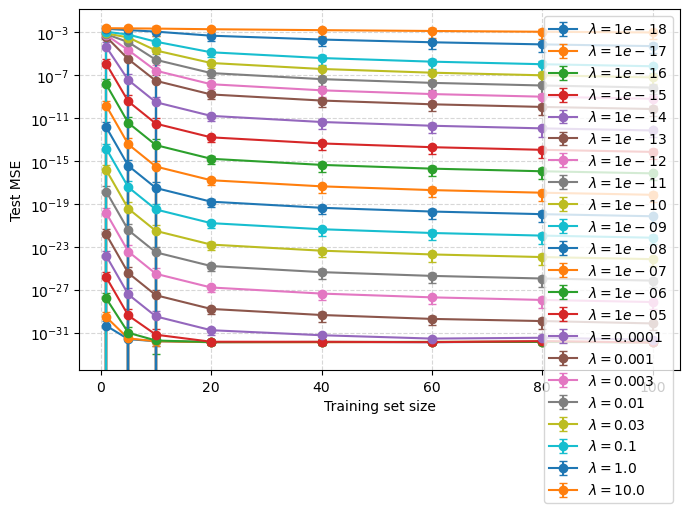

In [2]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="o",
        capsize=3,
        label=rf"$\lambda={lam}$"
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
def plot_n100_lambda_alpha(results, SEEDS, TRAIN_SIZES, LAMBDAS, target_n=100, target_lambda=1e-15):
    
    n_seeds = len(SEEDS)
    
    # ---- FIRST FIGURE: all seeds in subplots ----
    fig, axs = plt.subplots(2, n_seeds//2, figsize=(4*n_seeds//2, 8))
    axs = axs.flatten()
    
    for idx, seed in enumerate(SEEDS):
        res = results[seed]
        ti = TRAIN_SIZES.index(target_n)
        li = LAMBDAS.index(target_lambda)
        n = TRAIN_SIZES[ti]
        
        y_train = res["train_actuals"][ti, :n]
        y_test  = res["test_actuals"][ti]
        meta = load_meta(seed)
        X_train = np.array([x[0] for x in meta["X_train"][:n]])
        X_test  = np.array([x[0] for x in meta["X_test"]])
        
        xs_dense = np.linspace(min(X_train.min(), X_test.min()),
                               max(X_train.max(), X_test.max()), 400)
        alpha = res["alpha"]
        ys_dense = np.array([U_return_expval(np.array([x]), alpha) for x in xs_dense])
        
        ax = axs[idx]
        ax.plot(xs_dense, ys_dense, linewidth=2, color="black", label="True function")
        ax.scatter(X_train, y_train, s=40, label="Train actual")
        ax.scatter(X_test, y_test, s=40, marker="s", label="Test actual")
        alpha_str = ", ".join([f"{a:.2f}" for a in alpha])
        ax.set_title(f"Seed {seed}\nα=[{alpha_str}]", fontsize=10)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        # ax.ticklabel_format(style='plain', axis='y')  # cleaner y-axis
    
    plt.tight_layout()
    plt.show()
    
    # ---- THEN individual plots as before ----
    for seed in SEEDS:
        res = results[seed]
        ti = TRAIN_SIZES.index(target_n)
        li = LAMBDAS.index(target_lambda)
        n = TRAIN_SIZES[ti]
        
        y_train = res["train_actuals"][ti, :n]
        y_test  = res["test_actuals"][ti]
        meta = load_meta(seed)
        X_train = np.array([x[0] for x in meta["X_train"][:n]])
        X_test  = np.array([x[0] for x in meta["X_test"]])
        
        xs_dense = np.linspace(min(X_train.min(), X_test.min()),
                               max(X_train.max(), X_test.max()), 400)
        alpha = res["alpha"]
        ys_dense = np.array([U_return_expval(np.array([x]), alpha) for x in xs_dense])
        
        plt.figure(figsize=(7, 4))
        plt.plot(xs_dense, ys_dense, linewidth=3, color="black", label="True function")
        plt.scatter(X_train, y_train, s=80, label="Train actual")
        plt.scatter(X_test, y_test, s=80, marker="s", label="Test actual")
        
        alpha_str = ", ".join([f"{a:.2f}" for a in alpha])
        plt.title(f"Seed {seed} | λ={target_lambda:.1e} | α=[{alpha_str}]", fontsize=16)
        plt.xlabel("x", fontsize=14)
        plt.ylabel("f(x)", fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend(fontsize=12)
        # plt.ticklabel_format(style='plain', axis='y')
        plt.tight_layout()
        plt.show()

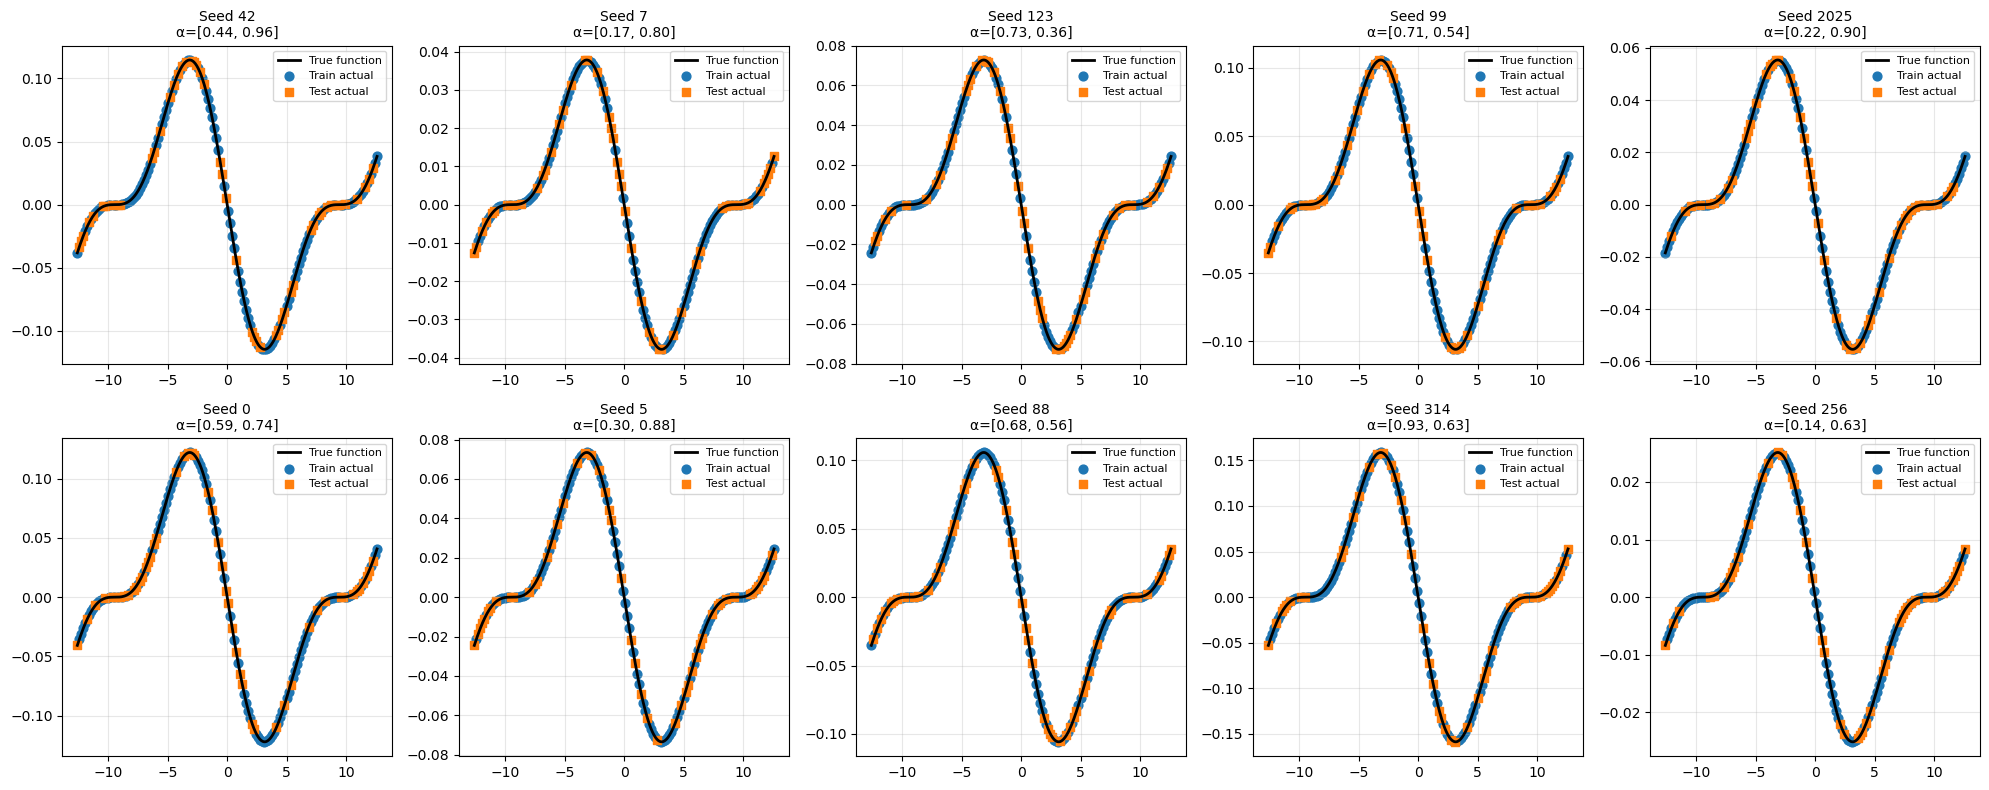

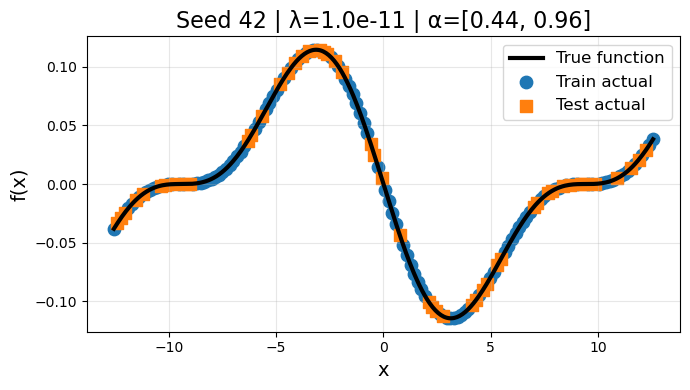

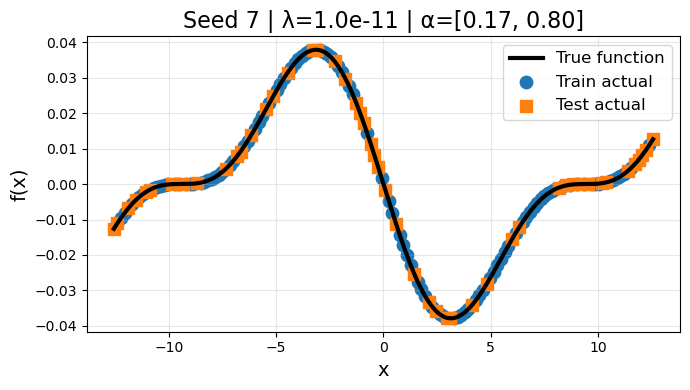

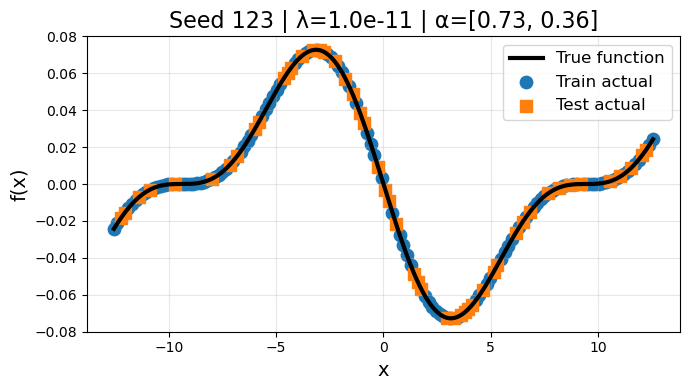

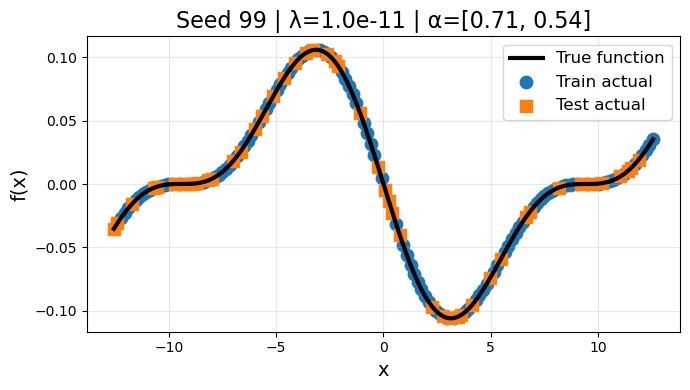

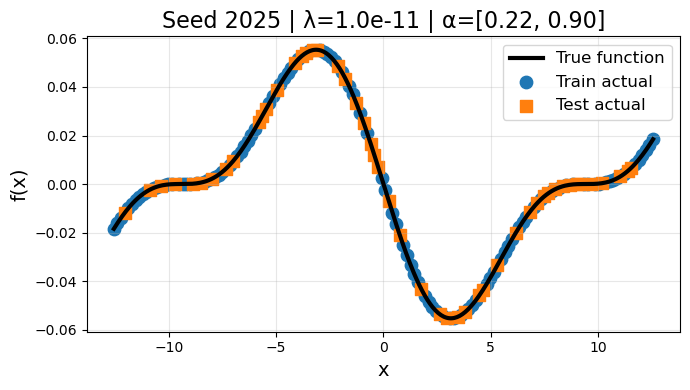

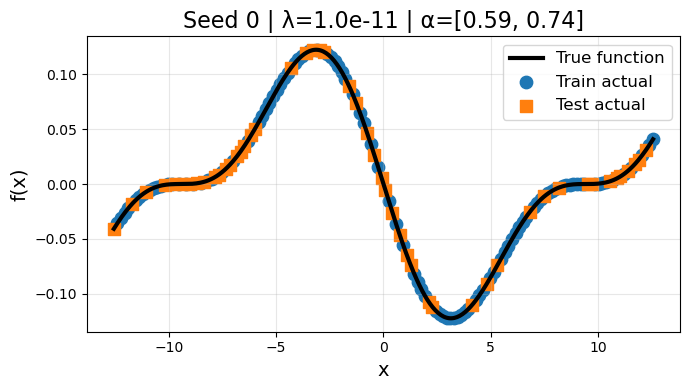

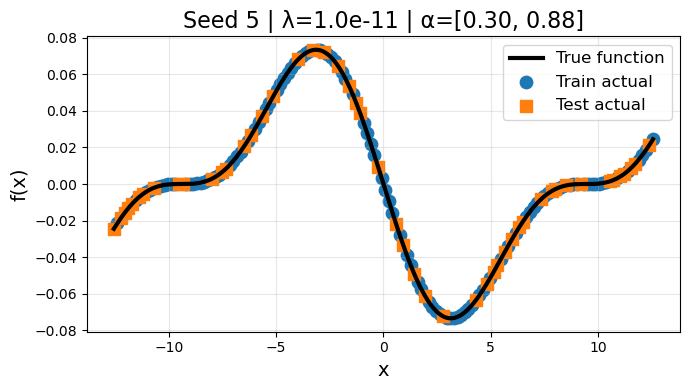

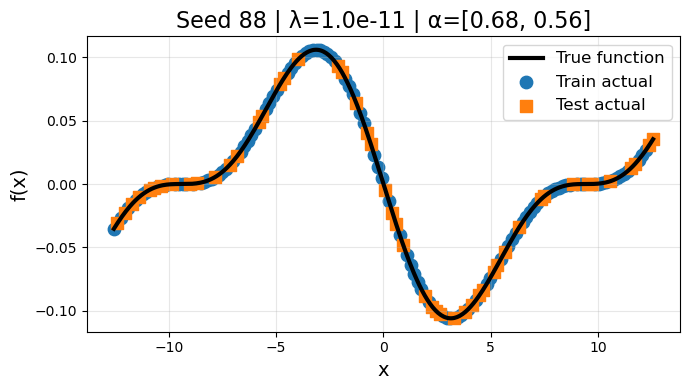

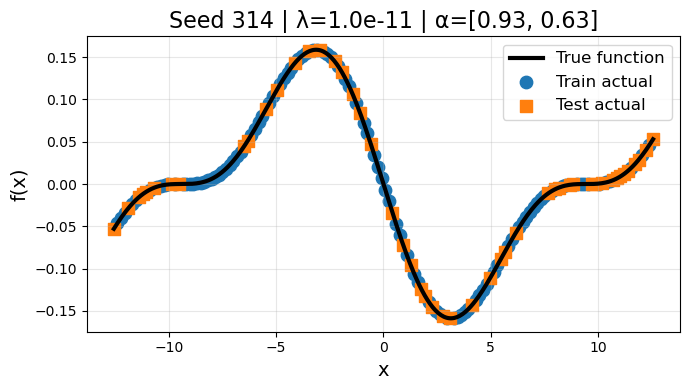

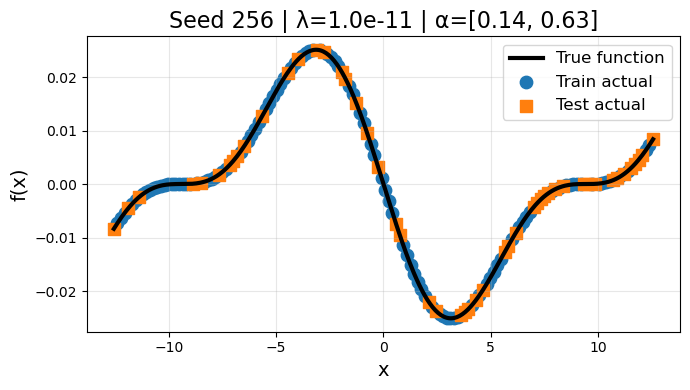

In [4]:
plot_n100_lambda_alpha(results, SEEDS, TRAIN_SIZES, LAMBDAS, target_n=100, target_lambda=1e-11)

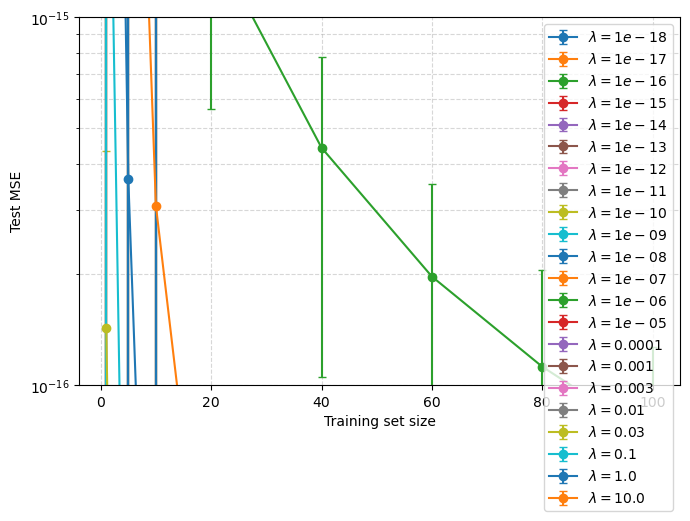

In [5]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="o",
        capsize=3,
        label=rf"$\lambda={lam}$"
    )

# plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-16,1e-15)
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import os

eps_machine = np.finfo(float).eps  # ~2.22e-16

for SEED in SEEDS:
    # Load kernel and train labels
    Ktr_path = os.path.join(seed_dir(SEED), "K_train.npy")
    K_train = load_or_init_matrix(Ktr_path, (N_TRAIN_MAX, N_TRAIN_MAX))

    meta = load_meta(SEED)
    Y_train = np.array(meta["Y_train"])  # shape: (N_TRAIN_MAX,)

    # Symmetrize kernel
    K_train = 0.5 * (K_train + K_train.T)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(K_train)
    eigvals_abs = np.abs(eigvals)

    # Project y onto eigenvectors
    y_proj = eigvecs.T @ Y_train  # y in eigenbasis

    # Estimate contribution to MSE from numerical errors
    # Directions with tiny eigenvalues get amplified
    delta_y = np.zeros_like(y_proj)
    for i, lam in enumerate(eigvals_abs):
        if lam > eps_machine:
            delta_y[i] = eps_machine * y_proj[i] / lam
        else:
            delta_y[i] = eps_machine * y_proj[i] / eps_machine  # cap at 1

    # Transform back to original basis
    delta_y_original = eigvecs @ delta_y

    mse_floor = np.mean(delta_y_original**2)

    print(f"Seed {SEED}: predicted numerical MSE floor ≈ {mse_floor:.3e}")


Seed 42: predicted numerical MSE floor ≈ 2.004e-32+0.000e+00j
Seed 7: predicted numerical MSE floor ≈ 1.170e-32+0.000e+00j
Seed 123: predicted numerical MSE floor ≈ 6.295e-33+0.000e+00j
Seed 99: predicted numerical MSE floor ≈ 1.043e-32+0.000e+00j
Seed 2025: predicted numerical MSE floor ≈ 1.089e-32+0.000e+00j
Seed 0: predicted numerical MSE floor ≈ 1.789e-32+0.000e+00j
Seed 5: predicted numerical MSE floor ≈ 8.617e-33+0.000e+00j
Seed 88: predicted numerical MSE floor ≈ 1.008e-32+0.000e+00j
Seed 314: predicted numerical MSE floor ≈ 1.878e-32+0.000e+00j
Seed 256: predicted numerical MSE floor ≈ 9.131e-33+0.000e+00j


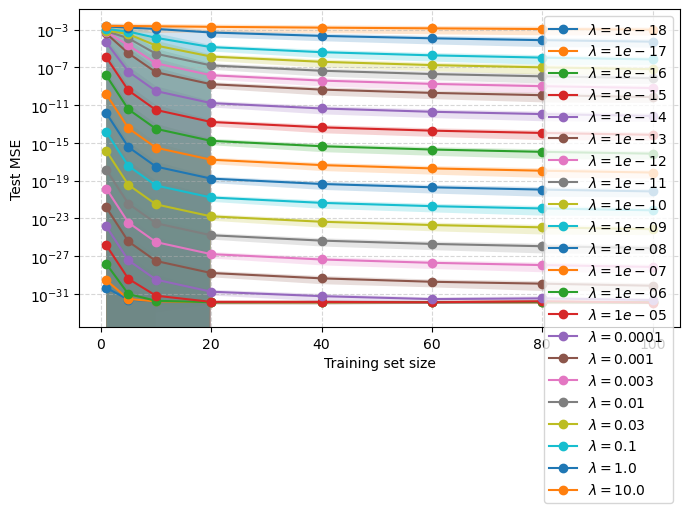

In [7]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    mean = res["test_mean"][:, li]
    std  = res["test_std"][:, li]

    plt.plot(
        TRAIN_SIZES,
        mean,
        marker="o",
        label=rf"$\lambda={lam}$"
    )
    plt.fill_between(
        TRAIN_SIZES,
        mean - std,
        mean + std,
        alpha=0.2
    )

# plt.xscale("log")   # turn on if train sizes span decades
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [8]:
for li, lam in enumerate(LAMBDAS):
    print(f"Lambda = {lam}")
    print(f"Train MSE = {res['train_mean'][:, li]}")
    print(f"Test MSE = {res['test_mean'][:, li]}")

Lambda = 1e-18
Train MSE = [6.24857532e-35 7.88971407e-33 1.14066968e-32 1.21769232e-32
 1.28453014e-32 1.28982223e-32 1.47553769e-32 1.25203040e-32]
Test MSE = [4.42675897e-31 2.49619692e-32 1.59139594e-32 1.31403109e-32
 1.35090386e-32 1.30634872e-32 1.42726797e-32 1.27533713e-32]
Lambda = 1e-17
Train MSE = [4.36962753e-33 7.69390145e-33 1.07758619e-32 1.22869474e-32
 1.22209650e-32 1.26828286e-32 1.54047301e-32 1.28052449e-32]
Test MSE = [2.82418647e-30 2.88488435e-32 1.59483381e-32 1.30461151e-32
 1.28942668e-32 1.36677531e-32 1.46580499e-32 1.25780938e-32]
Lambda = 1e-16
Train MSE = [4.35266860e-31 9.46264514e-33 1.13810652e-32 1.21991016e-32
 1.25561370e-32 1.29717525e-32 1.39918474e-32 1.30372942e-32]
Test MSE = [1.54252058e-28 9.75936815e-32 1.86628870e-32 1.31955176e-32
 1.36184279e-32 1.37296618e-32 1.36800720e-32 1.26427879e-32]
Lambda = 1e-15
Train MSE = [4.34894062e-29 2.01084002e-31 2.45946801e-32 1.25037132e-32
 1.28710903e-32 1.21842693e-32 1.62789885e-32 1.21450813e-32

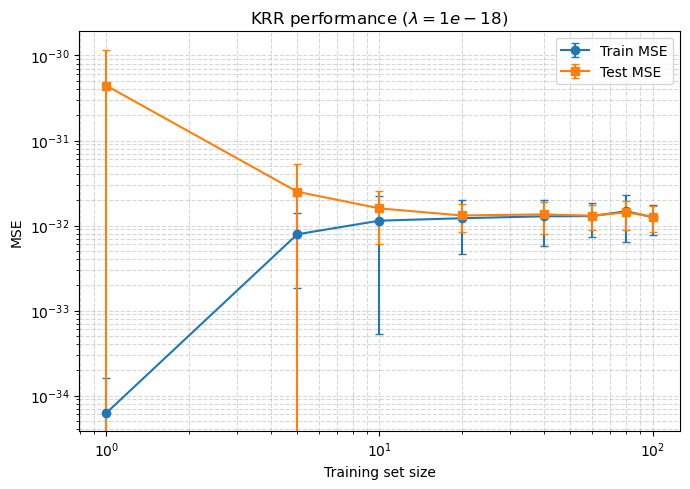

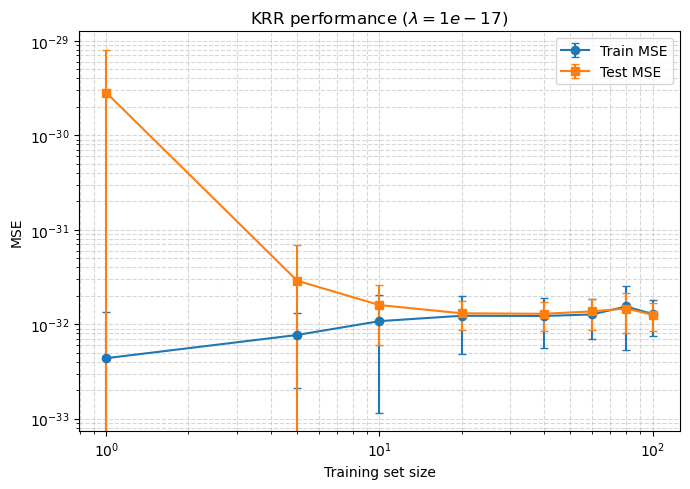

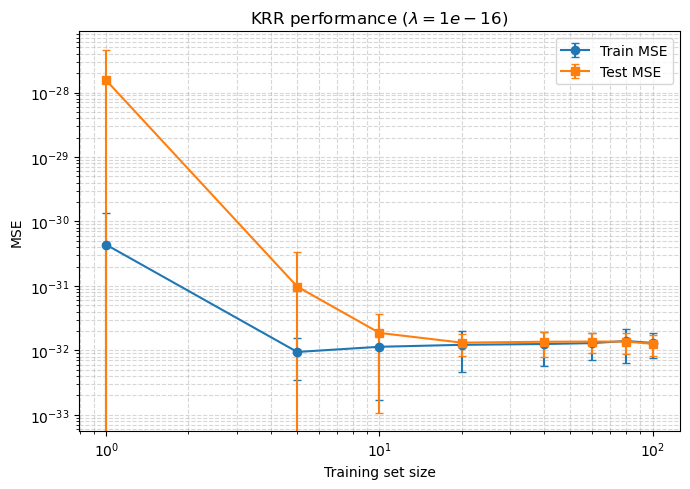

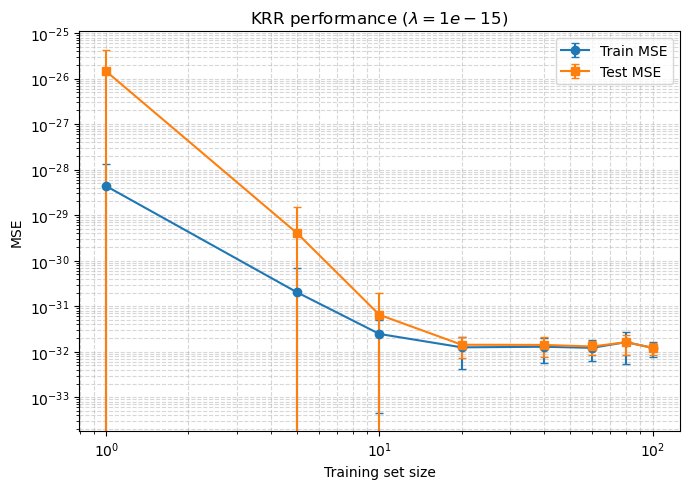

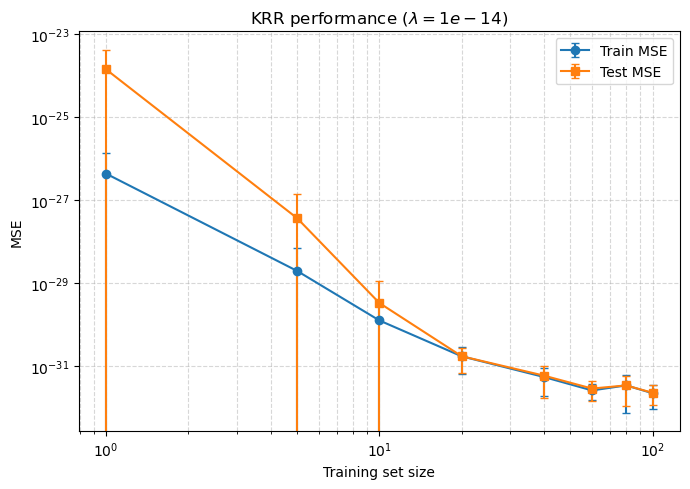

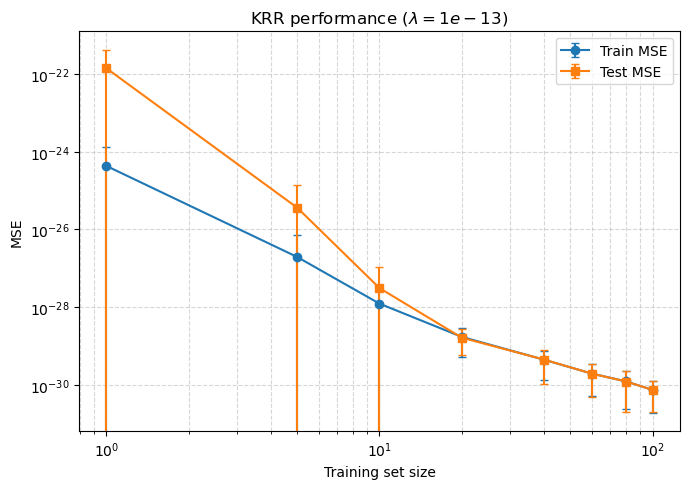

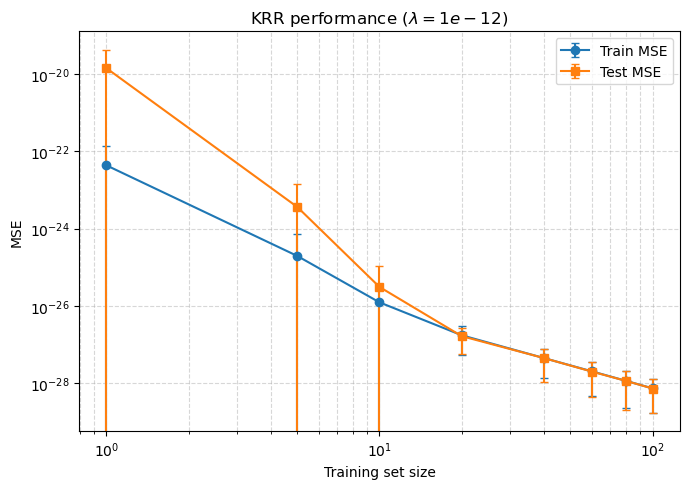

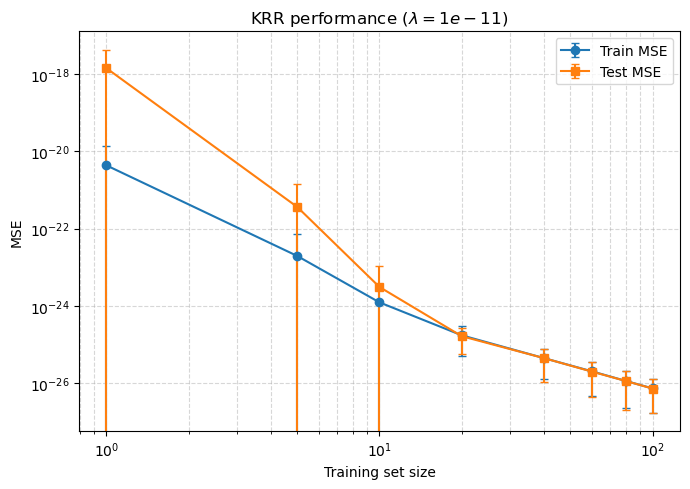

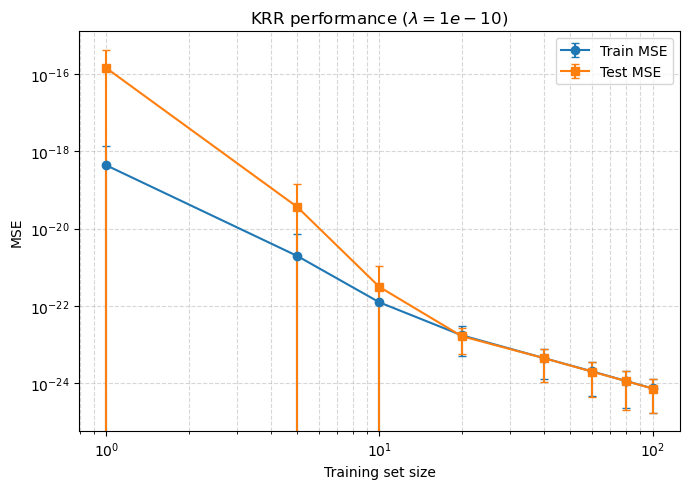

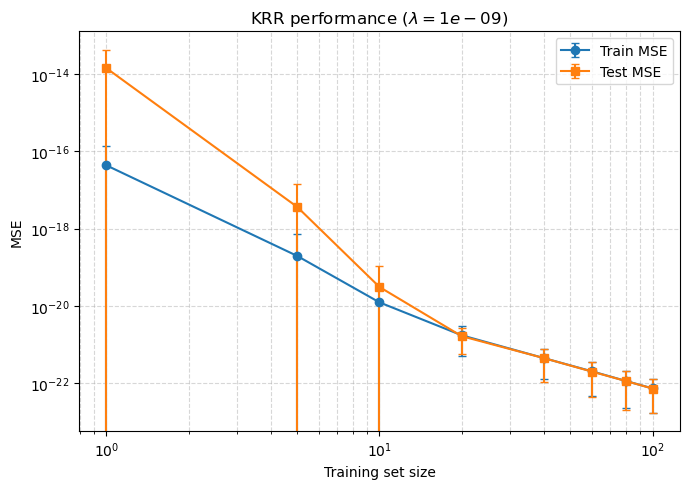

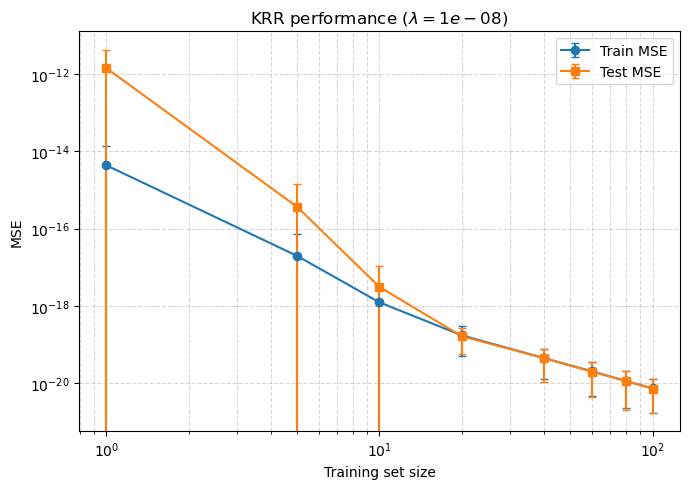

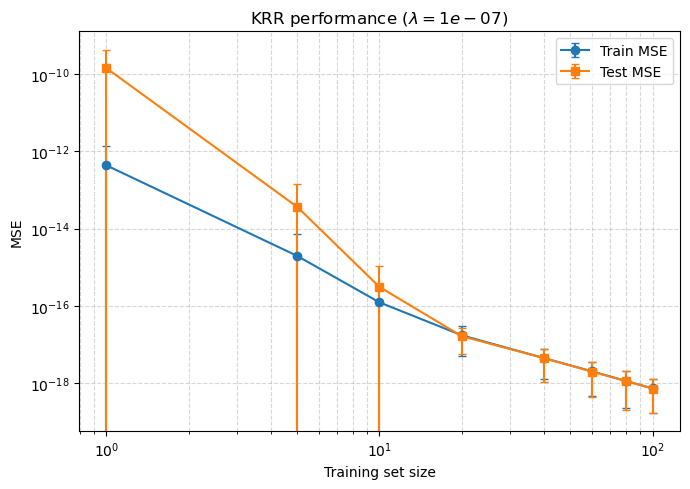

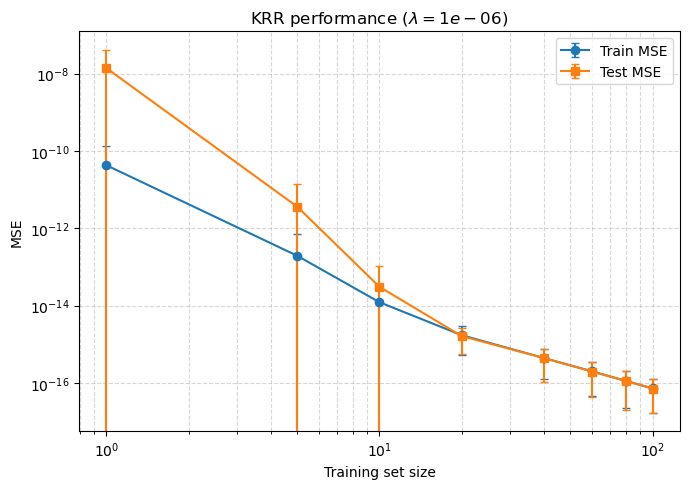

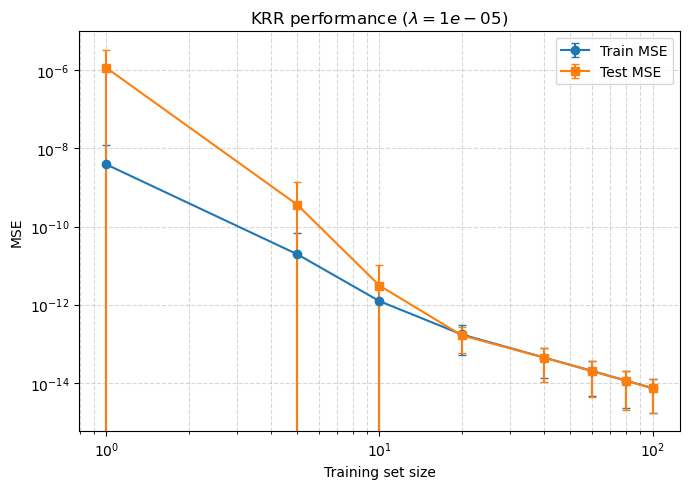

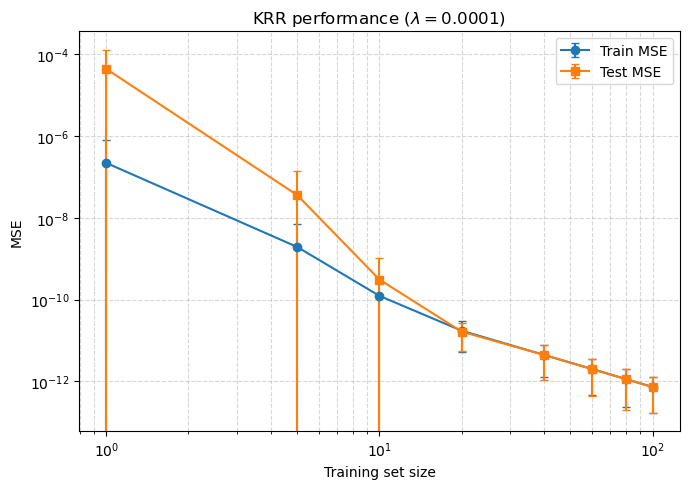

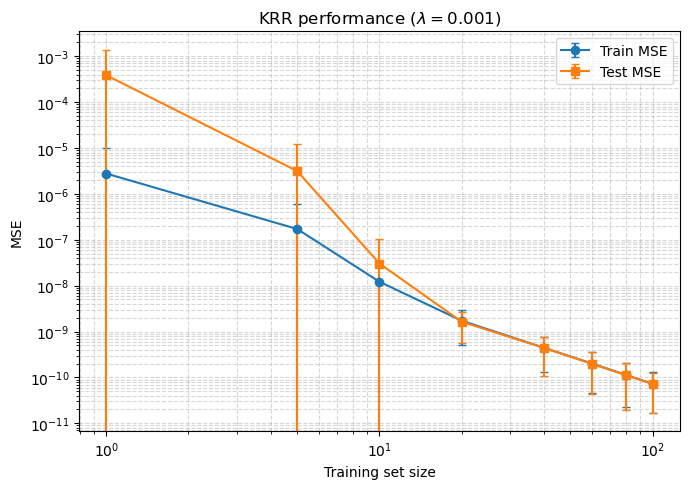

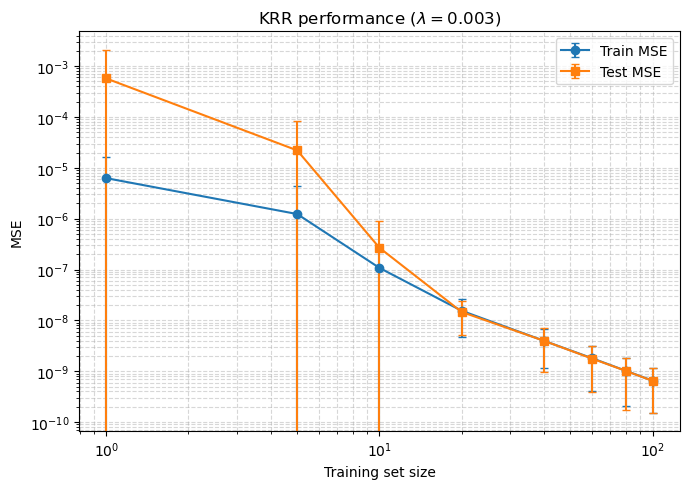

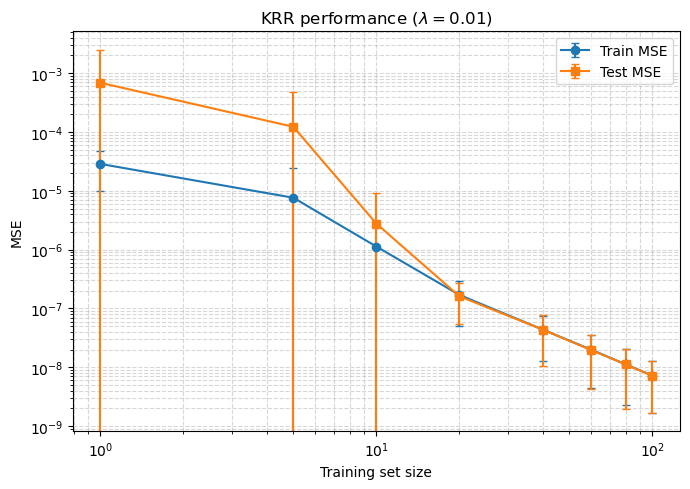

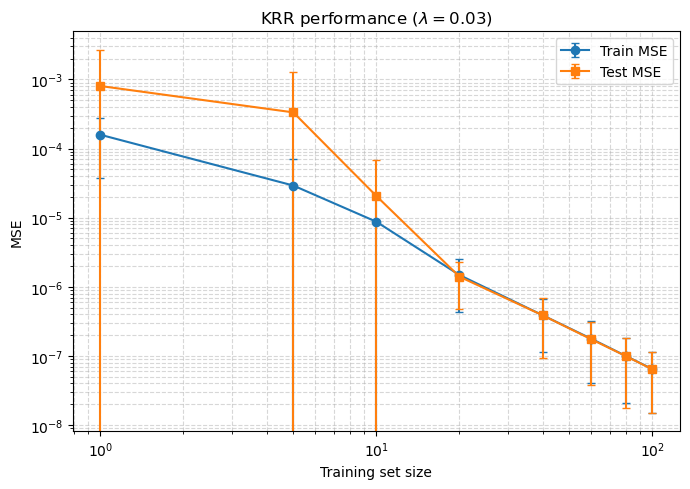

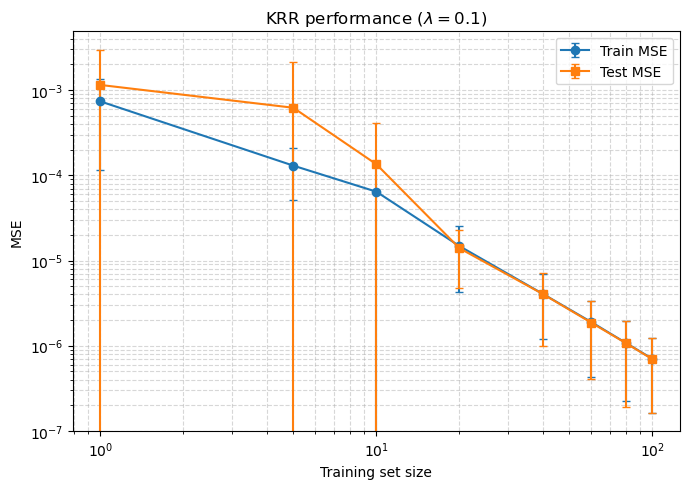

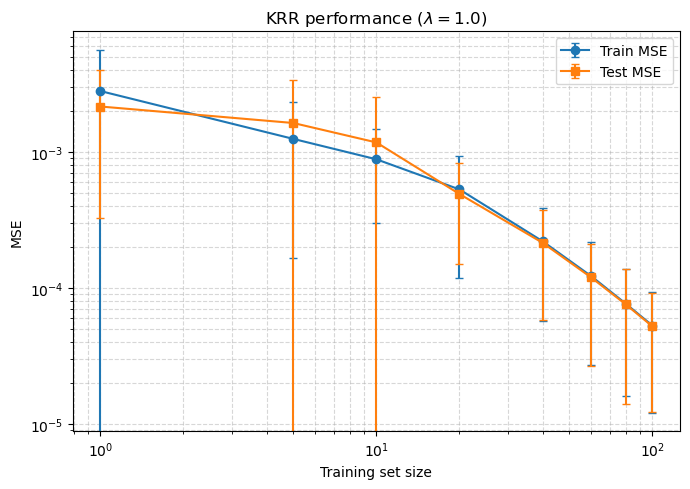

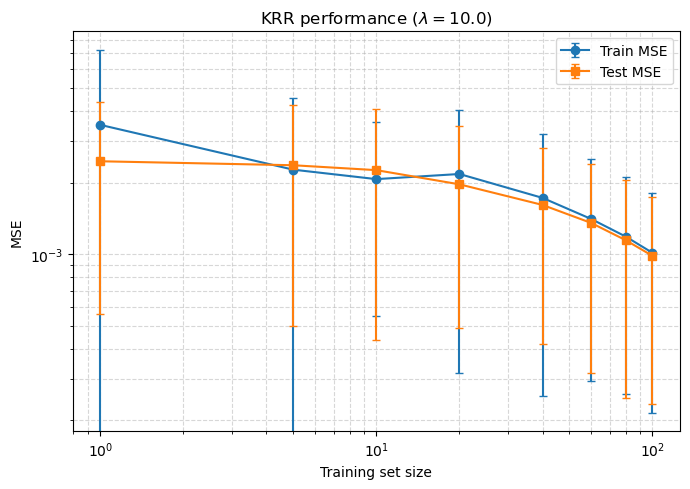

In [9]:
for li, lam in enumerate(LAMBDAS):
    plt.figure(figsize=(7,5))

    # Train
    plt.errorbar(
        TRAIN_SIZES,
        res["train_mean"][:, li],
        yerr=res["train_std"][:, li],
        marker="o",
        capsize=3,
        label="Train MSE"
    )

    # Test
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="s",
        capsize=3,
        label="Test MSE"
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Training set size")
    plt.ylabel("MSE")
    plt.title(rf"KRR performance ($\lambda={lam}$)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


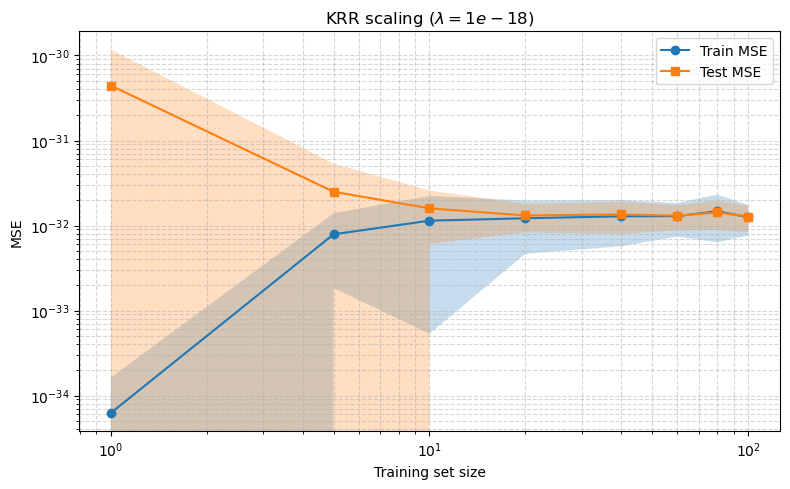

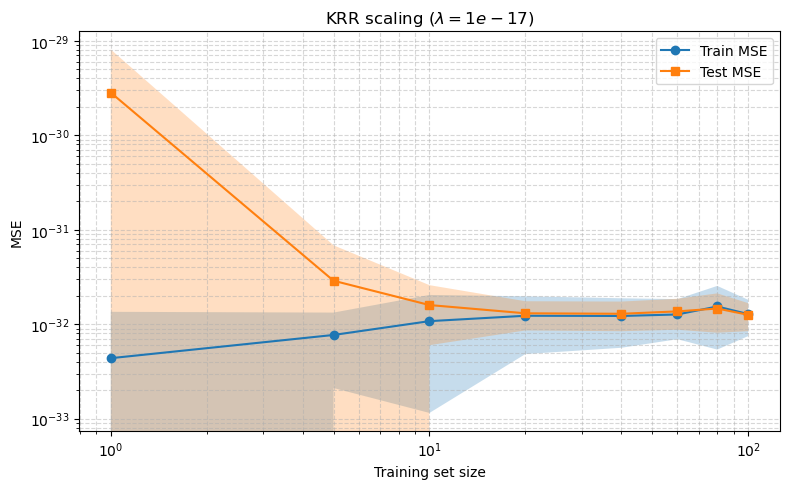

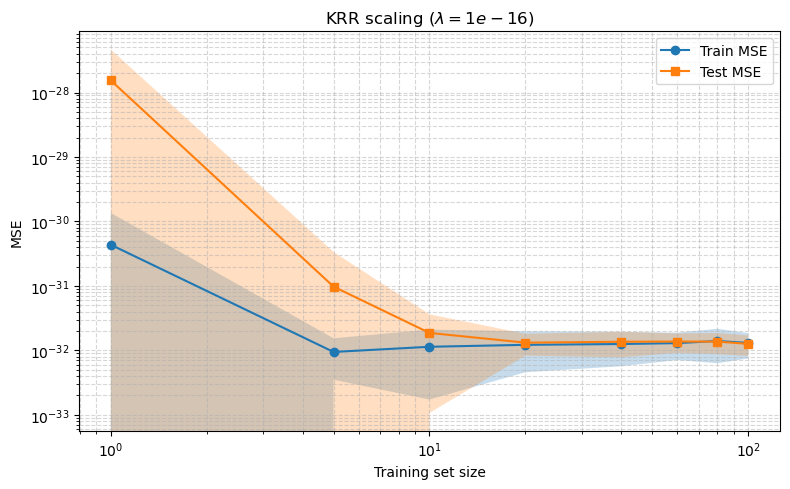

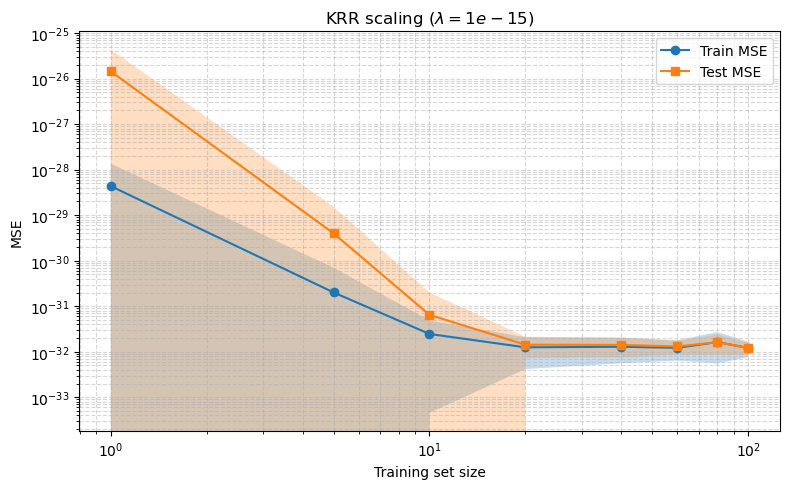

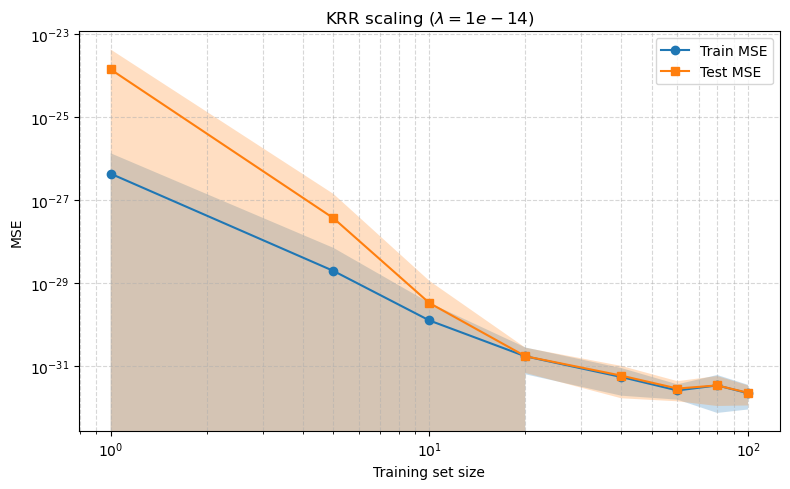

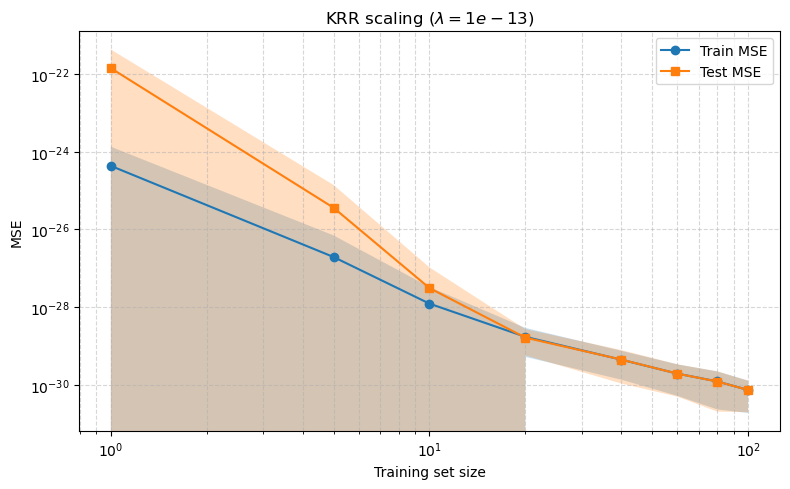

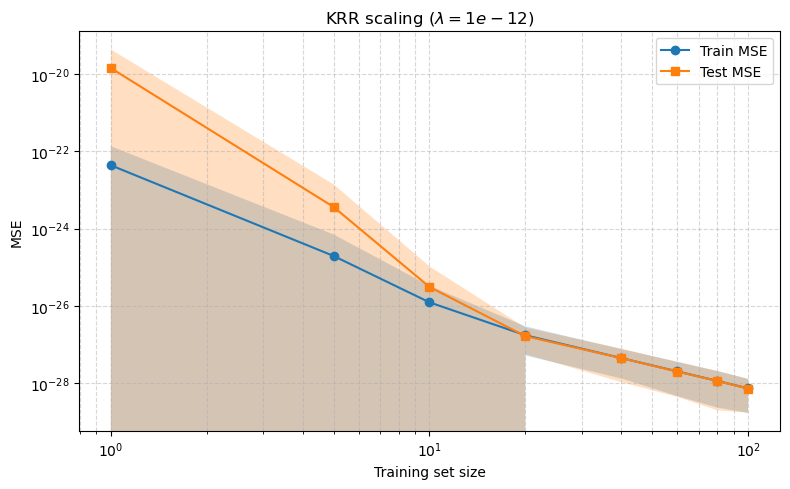

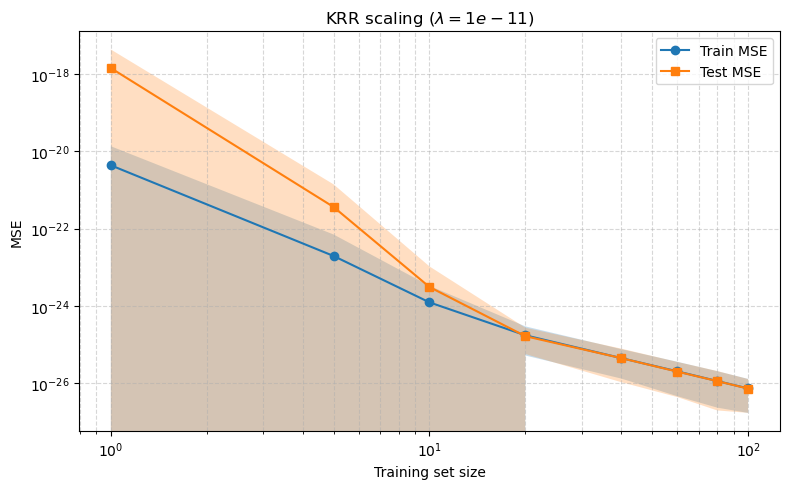

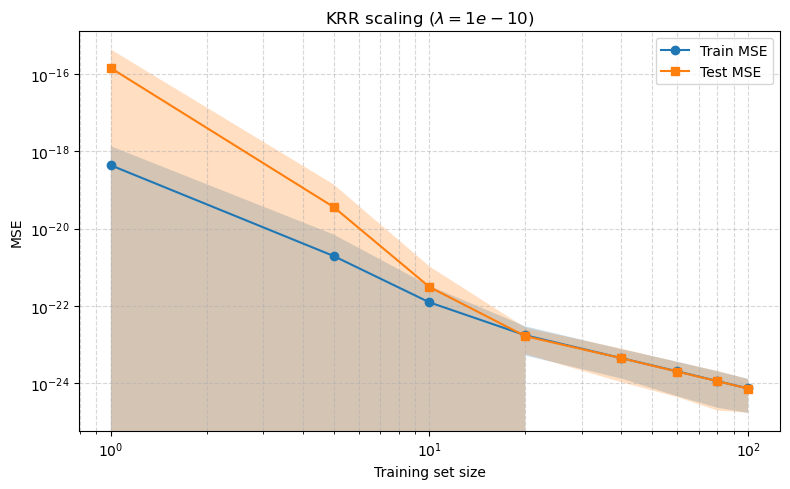

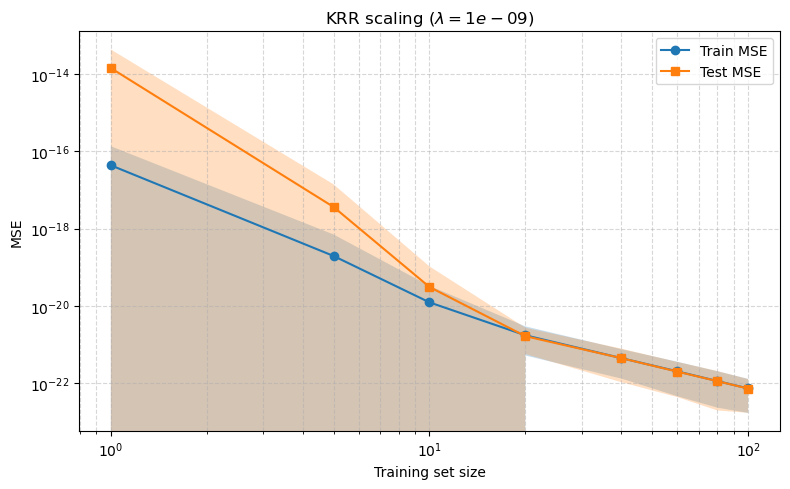

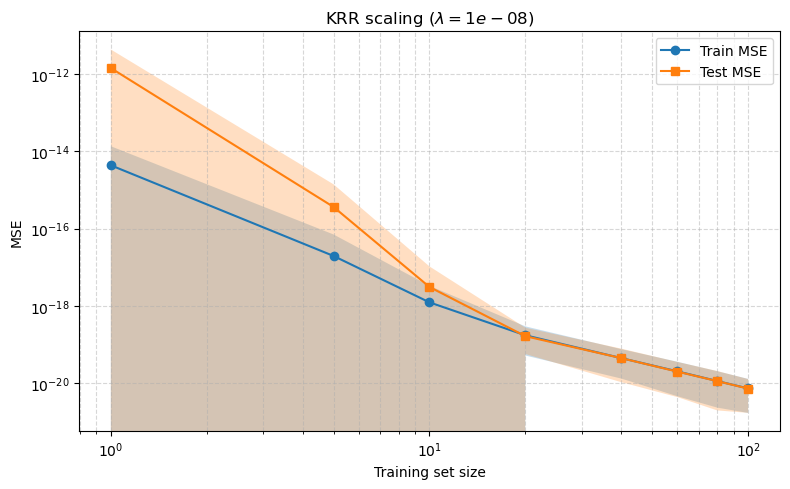

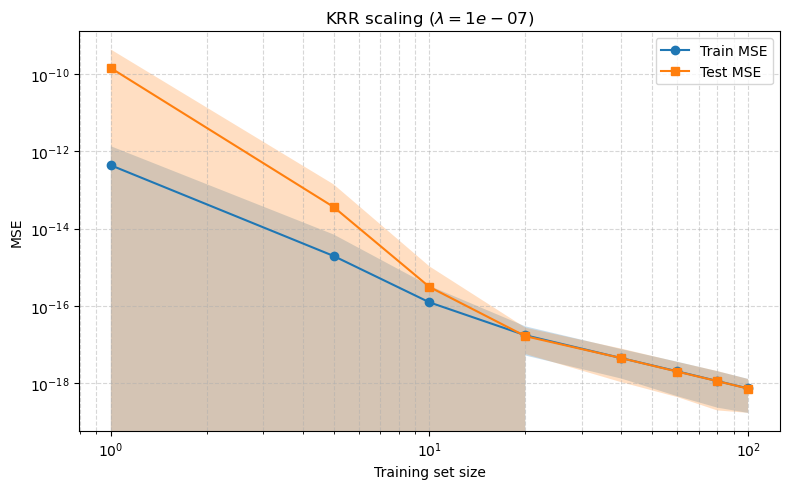

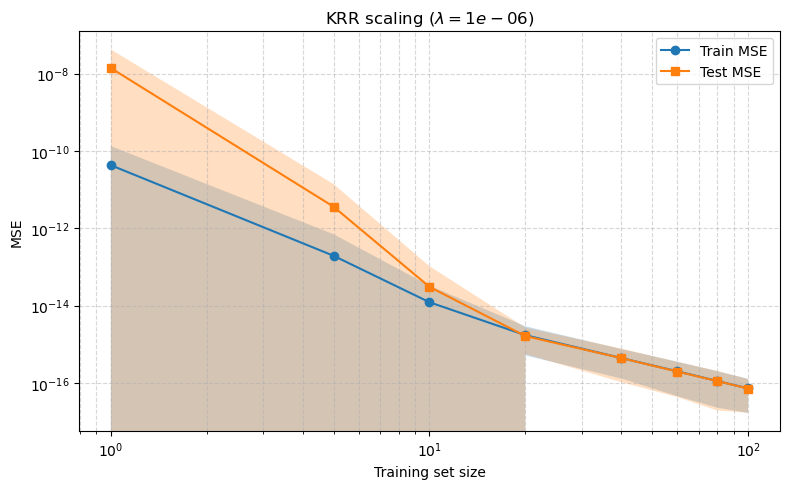

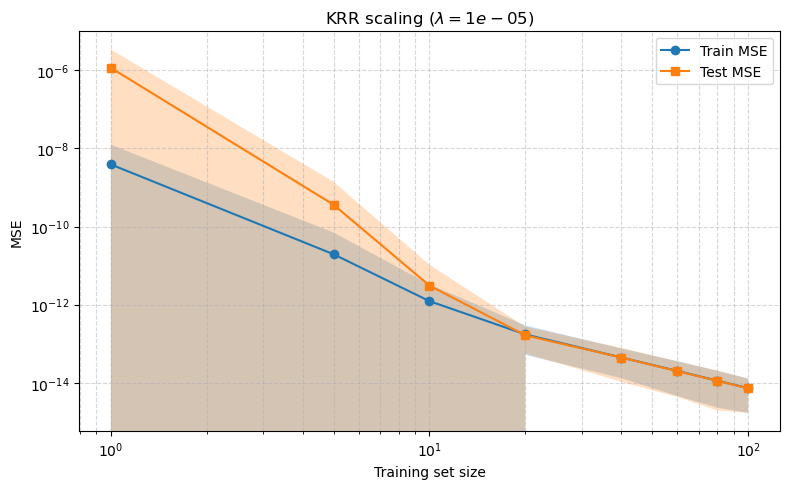

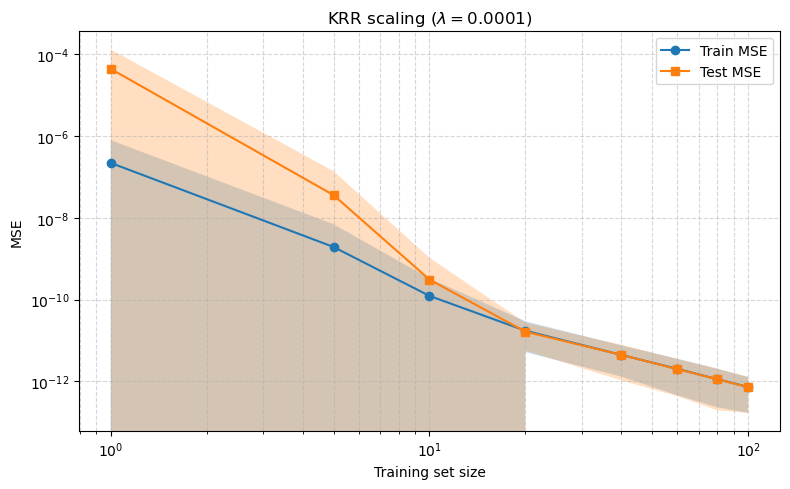

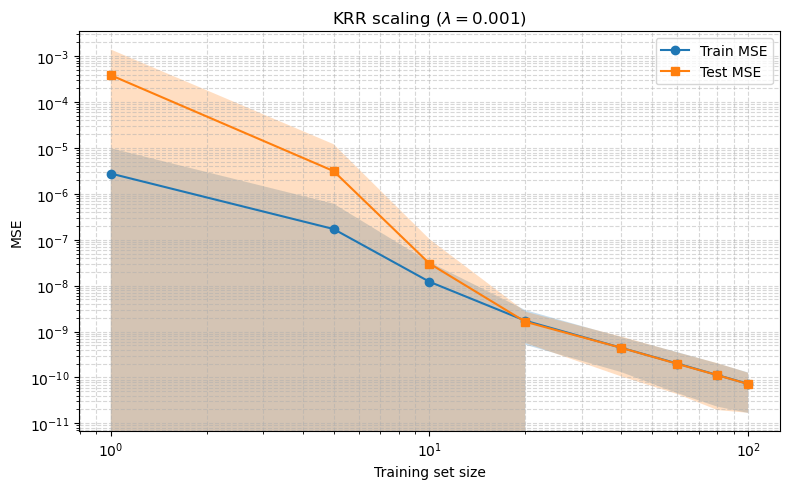

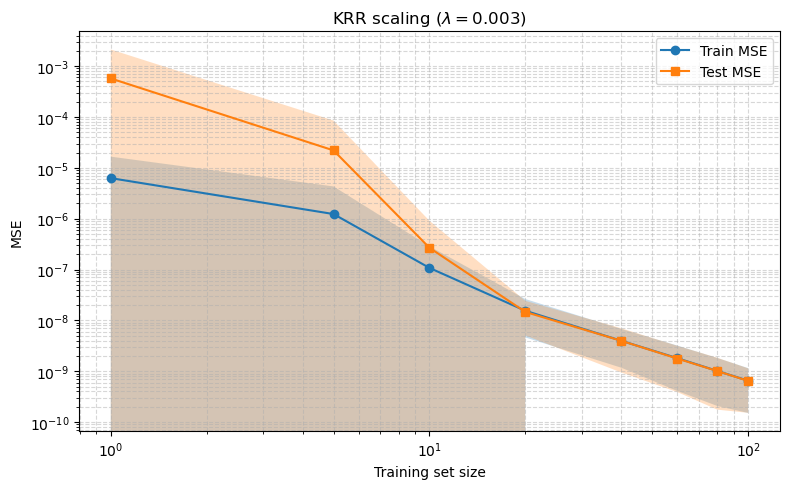

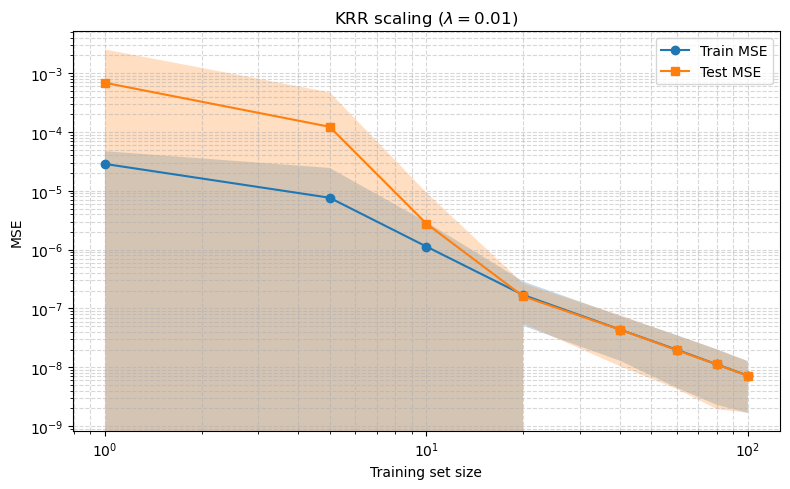

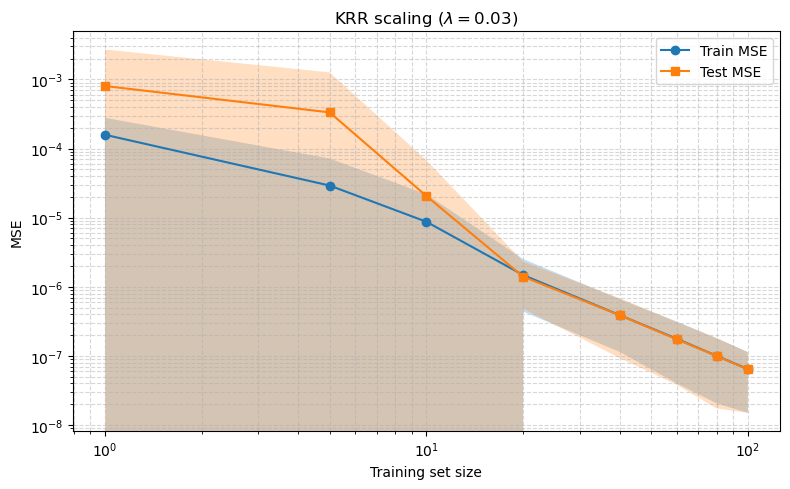

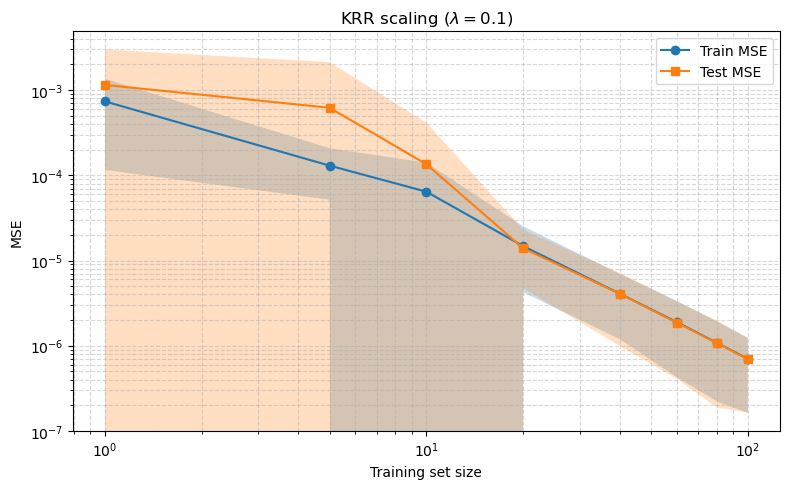

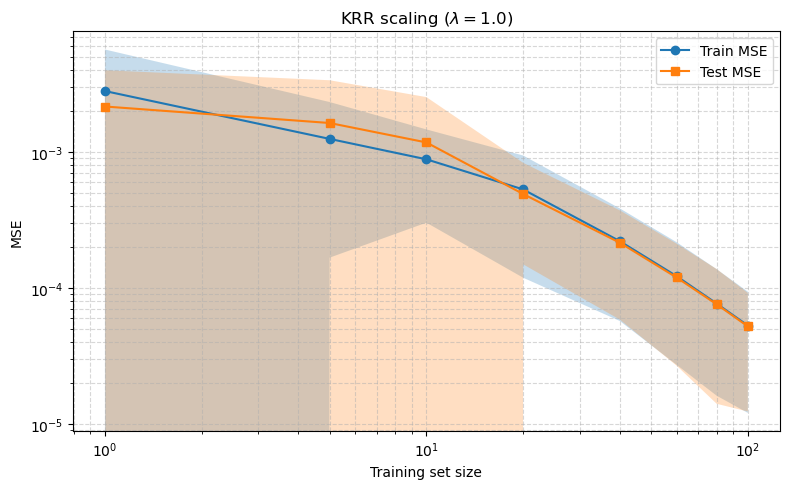

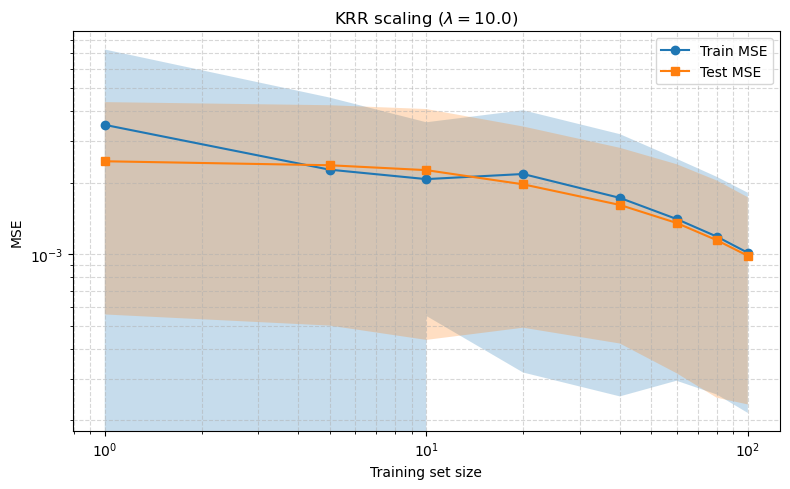

In [10]:
for li, lam in enumerate(LAMBDAS):
    plt.figure(figsize=(8,5))

    # Train MSE
    plt.plot(
        TRAIN_SIZES,
        res["train_mean"][:, li],
        "o-",
        label="Train MSE"
    )
    plt.fill_between(
        TRAIN_SIZES,
        res["train_mean"][:, li] - res["train_std"][:, li],
        res["train_mean"][:, li] + res["train_std"][:, li],
        alpha=0.25
    )

    # Test MSE
    plt.plot(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        "s-",
        label="Test MSE"
    )
    plt.fill_between(
        TRAIN_SIZES,
        res["test_mean"][:, li] - res["test_std"][:, li],
        res["test_mean"][:, li] + res["test_std"][:, li],
        alpha=0.25
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Training set size")
    plt.ylabel("MSE")
    plt.title(rf"KRR scaling ($\lambda={lam}$)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


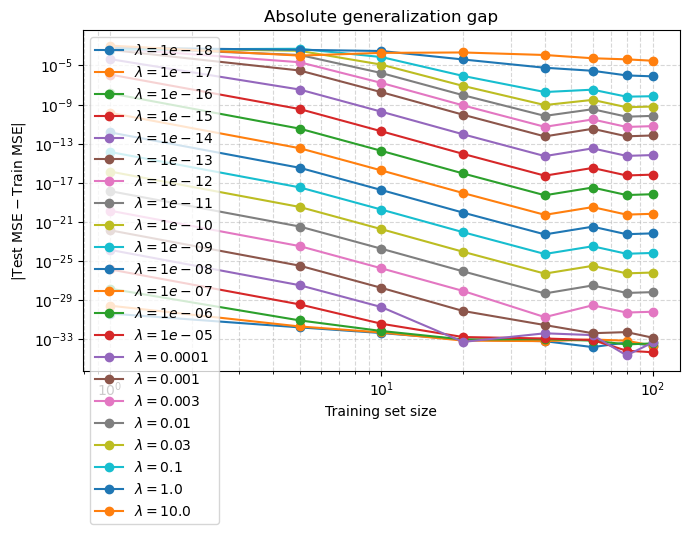

In [11]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    gap_abs = np.abs(
        res["test_mean"][:, li] - res["train_mean"][:, li]
    )

    plt.plot(
        TRAIN_SIZES,
        gap_abs,
        marker="o",
        label=rf"$\lambda={lam}$"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test\ MSE} - \mathrm{Train\ MSE}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


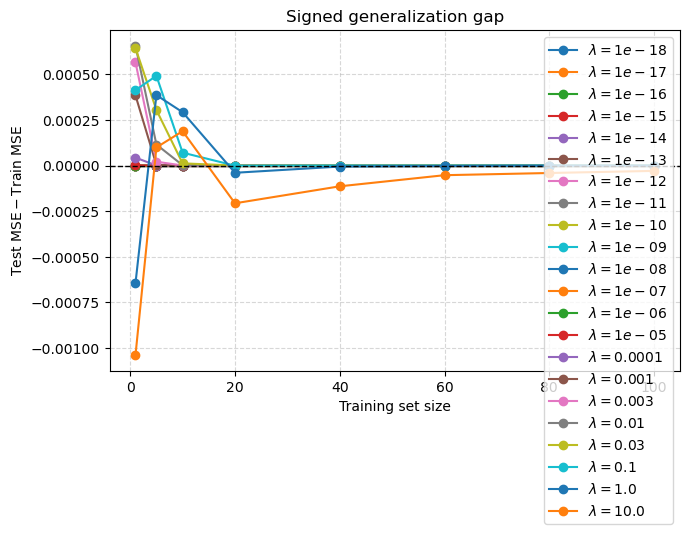

In [12]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    gap = res["test_mean"][:, li] - res["train_mean"][:, li]

    plt.plot(
        TRAIN_SIZES,
        gap,
        marker="o",
        label=rf"$\lambda={lam}$"
    )

# plt.xscale("log")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Training set size")
plt.ylabel(r"$\mathrm{Test\ MSE} - \mathrm{Train\ MSE}$")
plt.title("Signed generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()
